# Notebook 02 — Gradual Drift Detection: OCSVM vs Isolation Forest
### Population Drift in Deployed AI Medical Devices
**Cohorts:** Pima Indians Diabetes (n=768) · Frankfurt Hospital Glucose Dataset (n=2,000)

**Drift type:** Gradual multiplicative drift — linear ramp from 0% to severity (10%, 25%, 40%)  
**Scenarios:** Univariate (Glucose only) · Multivariate (Glucose + BMI + Age)  
**Algorithms:** OCSVM (γ=0.1, ν=0.05) · Isolation Forest (contamination=0.05, tuned via grid search)

**Pipeline:** Chronological 70/30 split → leak-free imputation/scaling → zero-drift control → DR measurement → K-S validation

In [1]:
# ================================================================
# IMPORTS
# ================================================================
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from scipy.stats import ks_2samp, spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import warnings
warnings.filterwarnings('ignore')
print("All imports successful.")

All imports successful.


In [2]:
# ================================================================
# CONFIGURATION
# ================================================================
DATASET_CONFIGS = {
    'Pima': {
        'step1_path': Path('data/interim/pima_step1_clean.csv'),
        'label'     : 'Pima Indians (n=768)',
    },
    'FHGD': {
        'step1_path': Path('data/interim/fhgd_step1_clean.csv'),
        'label'     : 'Frankfurt Hospital (n=2,000)',
    },
}

RESULTS_DIR   = Path('data/results')
REPORTS_DIR   = Path('reports/gradual_drift')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

DRIFT_FEATURES_MULTI = ['Glucose', 'BMI', 'Age']
DRIFT_LEVELS         = [0.10, 0.25, 0.40]

FEATURE_RANGES = {
    'Pregnancies'            : (0, 17),
    'Glucose'                : (70, 200),
    'BloodPressure'          : (40, 120),
    'SkinThickness'          : (7, 99),
    'Insulin'                : (14, 846),
    'BMI'                    : (15, 50),
    'DiabetesPedigreeFunction': (0.078, 2.42),
    'Age'                    : (21, 81),
}

COLS_WITH_MISSING = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print("Configuration loaded.")

Configuration loaded.


In [3]:
# ================================================================
# SECTION 0 — SHARED UTILITY FUNCTIONS (defined once)
# ================================================================

# ── Preprocessing ────────────────────────────────────────────────
def preprocess_dataset(step1_path):
    """Load step1_clean, create flags, 70/30 split, impute+scale on baseline only.
    Returns a dict with all pipeline objects needed downstream.
    """
    df = pd.read_csv(step1_path)
    for col in COLS_WITH_MISSING:
        df[f'{col}_is_missing'] = df[col].isna().astype(int)

    X = df.drop(columns='Outcome').sort_index()
    y = df['Outcome'].sort_index()
    split_point = int(0.7 * len(X))

    X_base_raw = X.iloc[:split_point].copy()
    X_test_raw = X.iloc[split_point:].copy()
    y_base     = y.iloc[:split_point].copy()
    y_test     = y.iloc[split_point:].copy()

    assert X_base_raw.index.max() < X_test_raw.index.min(), 'Index overlap!'

    indicator_cols = [c for c in X_base_raw.columns if c.endswith('_is_missing')]
    continuous_cols = [c for c in X_base_raw.columns if c not in indicator_cols]

    imputer = SimpleImputer(strategy='median')
    scaler  = StandardScaler()
    imputer.set_output(transform='pandas')
    scaler.set_output(transform='pandas')

    imputer.fit(X_base_raw[continuous_cols])
    X_base_imp  = imputer.transform(X_base_raw[continuous_cols])
    scaler.fit(X_base_imp)
    X_base_sc   = scaler.transform(X_base_imp)
    X_base_scaled = pd.concat([X_base_sc, X_base_raw[indicator_cols]], axis=1)

    X_test_imp  = imputer.transform(X_test_raw[continuous_cols])
    X_test_sc   = scaler.transform(X_test_imp)
    X_test_scaled = pd.concat([X_test_sc, X_test_raw[indicator_cols]], axis=1)

    return dict(X_base_raw=X_base_raw, X_test_raw=X_test_raw,
                X_base_scaled=X_base_scaled, X_test_scaled=X_test_scaled,
                imputer=imputer, scaler=scaler,
                indicator_cols=indicator_cols, continuous_cols=continuous_cols,
                y_base=y_base, y_test=y_test, n_total=len(df))


# ── Drift simulation ──────────────────────────────────────────────
def simulate_gradual_drift(df, feature, drift_percentage, duration, feature_ranges):
    """Apply gradual multiplicative drift to a single feature (linear ramp 0→drift_pct)."""
    df_d = df.copy()
    if pd.api.types.is_integer_dtype(df_d[feature]):
        df_d[feature] = df_d[feature].astype(float)

    n = min(int(duration), len(df_d))
    sched = np.linspace(0.0, float(drift_percentage), n) if n > 1 else np.array([float(drift_percentage)])

    orig = df_d[feature].iloc[:n].values
    new  = orig.copy()
    mask = ~np.isnan(orig)
    new[mask] = orig[mask] + orig[mask] * sched[mask]

    if feature in feature_ranges:
        lo, hi = feature_ranges[feature]
        new[mask] = np.clip(new[mask], lo, hi)

    df_d.loc[df_d.index[:n], feature] = new
    return df_d


def simulate_multivariate_drift(df, features_list, drift_percentage, duration, feature_ranges):
    """Apply gradual multiplicative drift to multiple features simultaneously."""
    df_d = df.copy()
    for feat in features_list:
        if pd.api.types.is_integer_dtype(df_d[feat]):
            df_d[feat] = df_d[feat].astype(float)

    n = min(int(duration), len(df_d))
    sched = np.linspace(0.0, float(drift_percentage), n) if n > 1 else np.array([float(drift_percentage)])

    for feat in features_list:
        orig = df_d[feat].iloc[:n].values
        new  = orig.copy()
        mask = ~np.isnan(orig)
        new[mask] = orig[mask] + orig[mask] * sched[mask]
        if feat in feature_ranges:
            lo, hi = feature_ranges[feat]
            new[mask] = np.clip(new[mask], lo, hi)
        df_d.loc[df_d.index[:n], feat] = new
    return df_d


# ── Experiment runners ────────────────────────────────────────────
def _apply_pipeline(X_raw_drifted, continuous_cols, indicator_cols, imputer, scaler):
    """Impute then scale a drifted raw dataframe; return scaled DataFrame."""
    X_imp = imputer.transform(X_raw_drifted[continuous_cols])
    X_sc  = pd.DataFrame(scaler.transform(X_imp),
                         columns=continuous_cols, index=X_raw_drifted.index)
    return pd.concat([X_sc, X_raw_drifted[indicator_cols]], axis=1)


def run_drift_experiment(data, model, drift_feature, drift_pct):
    """Univariate gradual drift: simulate → preprocess → predict → metrics."""
    X_tr  = data['X_test_raw']
    X_ts  = data['X_test_scaled']
    imp   = data['imputer']; sc = data['scaler']
    c_c   = data['continuous_cols']; i_c = data['indicator_cols']

    X_drifted_raw  = simulate_gradual_drift(X_tr.copy(), drift_feature,
                                             drift_pct, len(X_tr), FEATURE_RANGES)
    X_drifted_sc   = _apply_pipeline(X_drifted_raw, c_c, i_c, imp, sc)

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        y_orig    = model.predict(X_ts)
        y_drifted = model.predict(X_drifted_sc)

    r_orig    = (y_orig == -1).mean()
    r_drifted = (y_drifted == -1).mean()
    dr        = r_drifted / r_orig if r_orig > 0 else np.nan
    return dict(drift_amount=drift_pct, outlier_original=r_orig,
                outlier_drifted=r_drifted, detection_ratio=dr), X_drifted_sc


def run_multivariate_experiment(data, model, drift_pct):
    """Multivariate gradual drift on Glucose+BMI+Age."""
    X_tr = data['X_test_raw']; X_ts = data['X_test_scaled']
    imp  = data['imputer']; sc = data['scaler']
    c_c  = data['continuous_cols']; i_c = data['indicator_cols']

    X_drifted_raw = simulate_multivariate_drift(X_tr.copy(), DRIFT_FEATURES_MULTI,
                                                 drift_pct, len(X_tr), FEATURE_RANGES)
    X_drifted_sc  = _apply_pipeline(X_drifted_raw, c_c, i_c, imp, sc)

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        y_orig    = model.predict(X_ts)
        y_drifted = model.predict(X_drifted_sc)

    r_orig    = (y_orig == -1).mean()
    r_drifted = (y_drifted == -1).mean()
    dr        = r_drifted / r_orig if r_orig > 0 else np.nan
    return dict(drift_features='Glu+BMI+Age', drift_amount=drift_pct,
                outlier_original=r_orig, outlier_drifted=r_drifted, detection_ratio=dr), X_drifted_sc


# ── Statistical validation ────────────────────────────────────────
def run_ks_tests(X_base_scaled, X_drifted_scaled, scenario_label, features=None):
    """Two-sample K-S test comparing baseline vs drifted distributions."""
    if features is None:
        features = DRIFT_FEATURES_MULTI
    print(f'  K-S Tests — {scenario_label}:')
    for feat in features:
        ks, p = ks_2samp(X_base_scaled[feat], X_drifted_scaled[feat])
        verdict = 'DIFFERENT ✓' if p < 0.05 else 'unchanged'
        print(f'    {feat:<8}: KS={ks:.4f}  p={p:.2e}  → {verdict}')


# ── Summary helper ────────────────────────────────────────────────
def build_results_df(uni_list, multi_list, algo, dataset):
    rows = []
    for r in uni_list:
        rows.append(dict(dataset=dataset, algorithm=algo, scenario='Univariate',
                         **{k: v for k, v in r.items()}))
    for r in multi_list:
        rows.append(dict(dataset=dataset, algorithm=algo, scenario='Multivariate',
                         **{k: v for k, v in r.items() if k != 'drift_features'}))
    return pd.DataFrame(rows)

print("All utility functions defined.")

All utility functions defined.


In [4]:
# ================================================================
# RESULTS STORAGE
# ================================================================
all_gradual_results = {}   # keyed by dataset_name -> {ocsvm_uni, ocsvm_multi, if_uni, if_multi}
all_results_dfs     = []   # flat list for CSV export
print("Results storage initialised.")

Results storage initialised.


In [5]:
# ================================================================
# SECTION 1 — PIMA INDIANS DIABETES DATASET
# ================================================================
DS = 'Pima'
cfg = DATASET_CONFIGS[DS]
print(f'Loading and preprocessing {DS}...')
data_pima = preprocess_dataset(cfg['step1_path'])
print(f'  Baseline : {len(data_pima["X_base_raw"]):,} samples')
print(f'  Test     : {len(data_pima["X_test_raw"]):,} samples')
print(f'  Features : {len(data_pima["X_base_scaled"].columns)}')

Loading and preprocessing Pima...
  Baseline : 537 samples
  Test     : 231 samples
  Features : 13


In [6]:
# ──────────────────────────────────────────────────────────────────
# PIMA — OCSVM GRADUAL DRIFT
# ──────────────────────────────────────────────────────────────────
print('\n--- OCSVM Gradual Drift (Pima) ---')

X_base_sc_p = data_pima['X_base_scaled']
X_test_sc_p = data_pima['X_test_scaled']

# Gamma grid search
print('\nGamma grid search (nu=0.05):')
gamma_results = {}
for gamma in [0.001, 0.01, 0.1, 'scale']:
    m = OneClassSVM(kernel='rbf', gamma=gamma, nu=0.05)
    m.fit(X_base_sc_p)
    rate = (m.predict(X_base_sc_p) == -1).mean()
    gamma_results[str(gamma)] = rate
    print(f'  gamma={str(gamma):<6} -> baseline outlier rate: {rate:.3f}')

# Train final model (gamma=0.1 selected for drift sensitivity)
ocsvm_pima = OneClassSVM(kernel='rbf', gamma=0.1, nu=0.05)
ocsvm_pima.fit(X_base_sc_p)
print(f'\nFinal OCSVM trained: kernel=rbf, gamma=0.1, nu=0.05')
baseline_rate = (ocsvm_pima.predict(X_base_sc_p) == -1).mean()
print(f'Baseline (training) outlier rate: {baseline_rate:.1%}')


--- OCSVM Gradual Drift (Pima) ---

Gamma grid search (nu=0.05):
  gamma=0.001  -> baseline outlier rate: 0.052
  gamma=0.01   -> baseline outlier rate: 0.047
  gamma=0.1    -> baseline outlier rate: 0.056
  gamma=scale  -> baseline outlier rate: 0.074

Final OCSVM trained: kernel=rbf, gamma=0.1, nu=0.05
Baseline (training) outlier rate: 5.6%


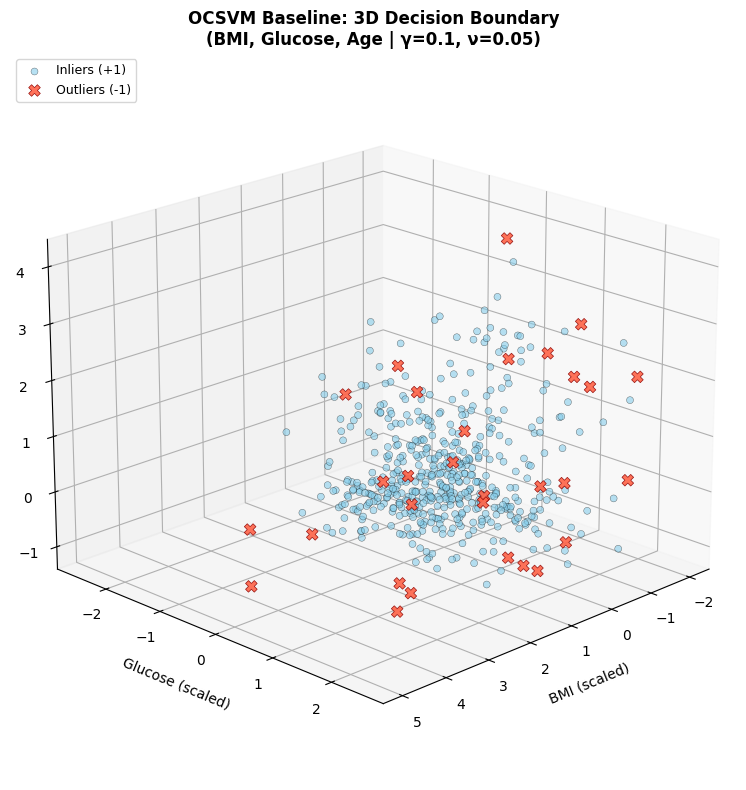

Inliers: 507 (94.4%) | Outliers: 30 (5.6%)


In [7]:
# OCSVM 3D decision boundary visualisation (gamma=0.1)
features_3d = ['BMI', 'Glucose', 'Age']
X3 = X_base_sc_p[features_3d].to_numpy()
y_pred_base_p = ocsvm_pima.predict(X_base_sc_p)
inl = (y_pred_base_p == 1); outl = (y_pred_base_p == -1)

fig = plt.figure(figsize=(11, 8))
ax  = fig.add_subplot(111, projection='3d')
ax.scatter(X3[inl,0],  X3[inl,1],  X3[inl,2],  c='skyblue', marker='o', s=25,
           alpha=0.6, edgecolors='k', linewidths=0.3, label='Inliers (+1)')
ax.scatter(X3[outl,0], X3[outl,1], X3[outl,2], c='tomato',  marker='X', s=70,
           alpha=0.9, edgecolors='darkred', linewidths=0.5, label='Outliers (-1)')
ax.set_xlabel('BMI (scaled)', labelpad=8)
ax.set_ylabel('Glucose (scaled)', labelpad=8)
ax.set_zlabel('Age (scaled)', labelpad=8)
ax.set_title('OCSVM Baseline: 3D Decision Boundary\n(BMI, Glucose, Age | γ=0.1, ν=0.05)',
             fontsize=12, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.view_init(elev=20, azim=45)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'ocsvm_pima_3d_boundary.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Inliers: {inl.sum()} ({inl.mean():.1%}) | Outliers: {outl.sum()} ({outl.mean():.1%})')

In [8]:
# Zero-drift control
zero_m, _ = run_drift_experiment(data_pima, ocsvm_pima, 'Glucose', 0.00)
zero_rate_ocsvm_p = zero_m['outlier_drifted']
print(f'OCSVM Pima — zero-drift control outlier rate: {zero_rate_ocsvm_p:.1%}')
assert abs(zero_m['detection_ratio'] - 1.0) < 1e-9, 'Zero-drift DR should be 1.0'
print('Zero-drift assertion PASSED (DR = 1.00x)')

OCSVM Pima — zero-drift control outlier rate: 11.7%
Zero-drift assertion PASSED (DR = 1.00x)


In [9]:
# Univariate drift experiments (Glucose)
print('\nOCSVM Pima — Univariate Drift (Glucose):')
ocsvm_p_uni = []
for dp in DRIFT_LEVELS:
    met, Xd = run_drift_experiment(data_pima, ocsvm_pima, 'Glucose', dp)
    ocsvm_p_uni.append(met)
    print(f'  {int(dp*100):>3}%: orig={met["outlier_original"]:.1%}  '
          f'drifted={met["outlier_drifted"]:.1%}  DR={met["detection_ratio"]:.2f}x')

# Monotonicity check
rho_u = spearmanr(DRIFT_LEVELS, [r['detection_ratio'] for r in ocsvm_p_uni]).statistic
print(f'  Spearman ρ (monotonicity): {rho_u:.3f}')


OCSVM Pima — Univariate Drift (Glucose):
   10%: orig=11.7%  drifted=11.7%  DR=1.00x
   25%: orig=11.7%  drifted=14.3%  DR=1.22x
   40%: orig=11.7%  drifted=17.3%  DR=1.48x
  Spearman ρ (monotonicity): 1.000


In [10]:
# Multivariate drift experiments (Glucose + BMI + Age)
print('\nOCSVM Pima — Multivariate Drift (Glu+BMI+Age):')
ocsvm_p_multi = []
X_drifted_severe_ocsvm_p = None
for dp in DRIFT_LEVELS:
    met, Xd = run_multivariate_experiment(data_pima, ocsvm_pima, dp)
    ocsvm_p_multi.append(met)
    if abs(dp - 0.40) < 1e-9: X_drifted_severe_ocsvm_p = Xd
    print(f'  {int(dp*100):>3}%: orig={met["outlier_original"]:.1%}  '
          f'drifted={met["outlier_drifted"]:.1%}  DR={met["detection_ratio"]:.2f}x')

rho_m = spearmanr(DRIFT_LEVELS, [r['detection_ratio'] for r in ocsvm_p_multi]).statistic
print(f'  Spearman ρ (monotonicity): {rho_m:.3f}')


OCSVM Pima — Multivariate Drift (Glu+BMI+Age):
   10%: orig=11.7%  drifted=12.1%  DR=1.04x
   25%: orig=11.7%  drifted=16.9%  DR=1.44x
   40%: orig=11.7%  drifted=24.2%  DR=2.07x
  Spearman ρ (monotonicity): 1.000


In [11]:
# K-S validation — OCSVM Pima (40% severe drift)
print('\nK-S Validation — OCSVM Pima:')

# Univariate 40% drift
_, Xd_uni_40 = run_drift_experiment(data_pima, ocsvm_pima, 'Glucose', 0.40)
run_ks_tests(data_pima['X_test_scaled'], Xd_uni_40, 'Univariate 40%', ['Glucose', 'BMI', 'Age'])

# Multivariate 40% drift
run_ks_tests(data_pima['X_test_scaled'], X_drifted_severe_ocsvm_p,
             'Multivariate 40%', DRIFT_FEATURES_MULTI)


K-S Validation — OCSVM Pima:
  K-S Tests — Univariate 40%:
    Glucose : KS=0.2987  p=1.71e-09  → DIFFERENT ✓
    BMI     : KS=0.0000  p=1.00e+00  → unchanged
    Age     : KS=0.0000  p=1.00e+00  → unchanged
  K-S Tests — Multivariate 40%:
    Glucose : KS=0.2987  p=1.71e-09  → DIFFERENT ✓
    BMI     : KS=0.3420  p=2.26e-12  → DIFFERENT ✓
    Age     : KS=0.2814  p=1.85e-08  → DIFFERENT ✓


In [12]:
# ──────────────────────────────────────────────────────────────────
# PIMA — ISOLATION FOREST GRADUAL DRIFT
# ──────────────────────────────────────────────────────────────────
print('\n--- Isolation Forest Gradual Drift (Pima) ---')

# Hyperparameter grid search on 80/20 baseline split
X_tune, X_val = train_test_split(X_base_sc_p, test_size=0.2, random_state=42)
best_score = float('inf'); best_params_p = {}

print(f'\n{"n_est":<10} {"max_samp":<12} {"Val outlier rate":<22} {"Diff from 0.05"}')
print('-'*60)
for n_est in [100, 200, 300]:
    for max_samp in [128, 256, 'auto']:
        m = IsolationForest(n_estimators=n_est, max_samples=max_samp,
                            contamination=0.05, random_state=42, n_jobs=-1)
        m.fit(X_tune)
        val_rate = (m.predict(X_val) == -1).mean()
        score    = abs(val_rate - 0.05)
        print(f'{n_est:<10} {str(max_samp):<12} {val_rate:.4f}{"":<16} {score:.4f}')
        if score < best_score:
            best_score = score
            best_params_p = {'n_estimators': n_est, 'max_samples': max_samp}
print('-'*60)
print(f'Best params (Pima): {best_params_p}')

# Train final IF model
if_pima = IsolationForest(**best_params_p, contamination=0.05, random_state=42, n_jobs=-1)
if_pima.fit(X_base_sc_p)
print(f'IF trained: {best_params_p}, contamination=0.05')


--- Isolation Forest Gradual Drift (Pima) ---

n_est      max_samp     Val outlier rate       Diff from 0.05
------------------------------------------------------------
100        128          0.0093                 0.0407
100        256          0.0278                 0.0222
100        auto         0.0278                 0.0222
200        128          0.0185                 0.0315
200        256          0.0278                 0.0222
200        auto         0.0278                 0.0222
300        128          0.0000                 0.0500
300        256          0.0278                 0.0222
300        auto         0.0278                 0.0222
------------------------------------------------------------
Best params (Pima): {'n_estimators': 100, 'max_samples': 256}
IF trained: {'n_estimators': 100, 'max_samples': 256}, contamination=0.05


In [13]:
# IF Pima — zero-drift control
yhat_if_zero_p = if_pima.predict(data_pima['X_test_scaled'])
zero_rate_if_p = (yhat_if_zero_p == -1).mean()
print(f'IF Pima zero-drift control outlier rate: {zero_rate_if_p:.1%}  (target: ~5.0%)')

IF Pima zero-drift control outlier rate: 2.2%  (target: ~5.0%)


In [14]:
# IF Pima — Univariate drift
print('\nIF Pima — Univariate Drift (Glucose):')
if_p_uni = []
for dp in DRIFT_LEVELS:
    met, Xd = run_drift_experiment(data_pima, if_pima, 'Glucose', dp)
    if_p_uni.append(met)
    print(f'  {int(dp*100):>3}%: orig={met["outlier_original"]:.1%}  '
          f'drifted={met["outlier_drifted"]:.1%}  DR={met["detection_ratio"]:.2f}x')

# IF Pima — Multivariate drift
print('\nIF Pima — Multivariate Drift (Glu+BMI+Age):')
if_p_multi = []
X_drifted_severe_if_p = None
for dp in DRIFT_LEVELS:
    met, Xd = run_multivariate_experiment(data_pima, if_pima, dp)
    if_p_multi.append(met)
    if abs(dp - 0.40) < 1e-9: X_drifted_severe_if_p = Xd
    print(f'  {int(dp*100):>3}%: orig={met["outlier_original"]:.1%}  '
          f'drifted={met["outlier_drifted"]:.1%}  DR={met["detection_ratio"]:.2f}x')

rho_if_u = spearmanr(DRIFT_LEVELS, [r['detection_ratio'] for r in if_p_uni]).statistic
rho_if_m = spearmanr(DRIFT_LEVELS, [r['detection_ratio'] for r in if_p_multi]).statistic
print(f'\nSpearman ρ — univariate: {rho_if_u:.3f} | multivariate: {rho_if_m:.3f}')


IF Pima — Univariate Drift (Glucose):
   10%: orig=2.2%  drifted=2.6%  DR=1.20x
   25%: orig=2.2%  drifted=2.6%  DR=1.20x
   40%: orig=2.2%  drifted=3.5%  DR=1.60x

IF Pima — Multivariate Drift (Glu+BMI+Age):
   10%: orig=2.2%  drifted=3.9%  DR=1.80x
   25%: orig=2.2%  drifted=6.5%  DR=3.00x
   40%: orig=2.2%  drifted=9.5%  DR=4.40x

Spearman ρ — univariate: 0.866 | multivariate: 1.000


In [15]:
# K-S validation — IF Pima
print('\nK-S Validation — IF Pima:')
_, Xd_if_uni_40 = run_drift_experiment(data_pima, if_pima, 'Glucose', 0.40)
run_ks_tests(data_pima['X_test_scaled'], Xd_if_uni_40, 'IF Univariate 40%', ['Glucose','BMI','Age'])
run_ks_tests(data_pima['X_test_scaled'], X_drifted_severe_if_p, 'IF Multivariate 40%', DRIFT_FEATURES_MULTI)


K-S Validation — IF Pima:
  K-S Tests — IF Univariate 40%:
    Glucose : KS=0.2987  p=1.71e-09  → DIFFERENT ✓
    BMI     : KS=0.0000  p=1.00e+00  → unchanged
    Age     : KS=0.0000  p=1.00e+00  → unchanged
  K-S Tests — IF Multivariate 40%:
    Glucose : KS=0.2987  p=1.71e-09  → DIFFERENT ✓
    BMI     : KS=0.3420  p=2.26e-12  → DIFFERENT ✓
    Age     : KS=0.2814  p=1.85e-08  → DIFFERENT ✓



--- Pima: OCSVM vs Isolation Forest Detection Ratios ---


,Drift%,Scenario,OCSVM DR,IF DR,Advantage
0,10,Univariate,1.000,1.2,IF
1,10,Multivariate,1.037,1.8,IF
2,25,Univariate,1.222,1.2,OCSVM
3,25,Multivariate,1.444,3.0,IF
4,40,Univariate,1.481,1.6,IF
5,40,Multivariate,2.074,4.4,IF


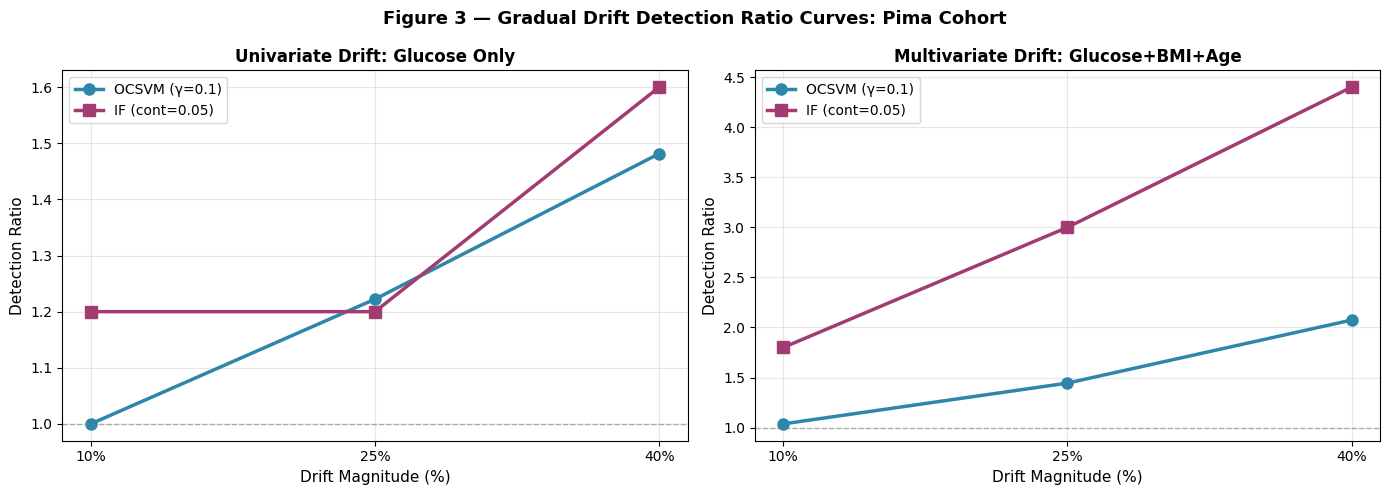


Pima results stored.


In [16]:
# ──────────────────────────────────────────────────────────────────
# PIMA — ALGORITHM COMPARISON TABLE + FIGURE 3
# ──────────────────────────────────────────────────────────────────
drift_pcts = [int(d*100) for d in DRIFT_LEVELS]

ocsvm_uni_drs   = [r['detection_ratio'] for r in ocsvm_p_uni]
ocsvm_multi_drs = [r['detection_ratio'] for r in ocsvm_p_multi]
if_uni_drs      = [r['detection_ratio'] for r in if_p_uni]
if_multi_drs    = [r['detection_ratio'] for r in if_p_multi]

# Comparison table
comp_rows = []
for i, dp in enumerate(drift_pcts):
    comp_rows.append({'Drift%': dp, 'Scenario': 'Univariate',
                      'OCSVM DR': round(ocsvm_uni_drs[i],3), 'IF DR': round(if_uni_drs[i],3),
                      'Advantage': 'IF' if if_uni_drs[i] > ocsvm_uni_drs[i] else 'OCSVM'})
    comp_rows.append({'Drift%': dp, 'Scenario': 'Multivariate',
                      'OCSVM DR': round(ocsvm_multi_drs[i],3), 'IF DR': round(if_multi_drs[i],3),
                      'Advantage': 'IF' if if_multi_drs[i] > ocsvm_multi_drs[i] else 'OCSVM'})
comp_df_p = pd.DataFrame(comp_rows)
print('\n--- Pima: OCSVM vs Isolation Forest Detection Ratios ---')
display(comp_df_p)

# Figure 3 — DR curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for ax, ocsvm_drs, if_drs, title in [
    (ax1, ocsvm_uni_drs,   if_uni_drs,   'Univariate Drift: Glucose Only'),
    (ax2, ocsvm_multi_drs, if_multi_drs, 'Multivariate Drift: Glucose+BMI+Age'),
]:
    ax.plot(drift_pcts, ocsvm_drs, marker='o', lw=2.5, ms=8, label='OCSVM (γ=0.1)', color='#2E86AB')
    ax.plot(drift_pcts, if_drs,    marker='s', lw=2.5, ms=8, label=f'IF (cont=0.05)', color='#A23B72')
    ax.axhline(1.0, color='grey', ls='--', lw=1, alpha=0.6)
    ax.set_xlabel('Drift Magnitude (%)', fontsize=11)
    ax.set_ylabel('Detection Ratio', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticks(drift_pcts); ax.set_xticklabels([f'{d}%' for d in drift_pcts])
    ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

plt.suptitle('Figure 3 — Gradual Drift Detection Ratio Curves: Pima Cohort',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'fig3_gradual_DR_pima.png', dpi=150, bbox_inches='tight')
plt.show()

# Store results
all_gradual_results['Pima'] = dict(
    ocsvm_uni=ocsvm_p_uni, ocsvm_multi=ocsvm_p_multi,
    if_uni=if_p_uni,       if_multi=if_p_multi,
    zero_ocsvm=zero_rate_ocsvm_p, zero_if=zero_rate_if_p,
)
all_results_dfs.append(build_results_df(ocsvm_p_uni, ocsvm_p_multi, 'OCSVM', 'Pima'))
all_results_dfs.append(build_results_df(if_p_uni,    if_p_multi,    'IF',    'Pima'))
print('\nPima results stored.')

In [17]:
# ================================================================
# SECTION 2 — FRANKFURT HOSPITAL GLUCOSE DATASET (FHGD)
# ================================================================
DS = 'FHGD'
cfg = DATASET_CONFIGS[DS]
print(f'Loading and preprocessing {DS}...')
data_fhgd = preprocess_dataset(cfg['step1_path'])
print(f'  Baseline : {len(data_fhgd["X_base_raw"]):,} samples')
print(f'  Test     : {len(data_fhgd["X_test_raw"]):,} samples')
print(f'  Features : {len(data_fhgd["X_base_scaled"].columns)}')

Loading and preprocessing FHGD...
  Baseline : 1,400 samples
  Test     : 600 samples
  Features : 13


In [18]:
# ──────────────────────────────────────────────────────────────────
# FHGD — OCSVM GRADUAL DRIFT
# ──────────────────────────────────────────────────────────────────
print('\n--- OCSVM Gradual Drift (FHGD) ---')

X_base_sc_f = data_fhgd['X_base_scaled']
X_test_sc_f = data_fhgd['X_test_scaled']

# Gamma grid search
print('\nGamma grid search (nu=0.05):')
for gamma in [0.001, 0.01, 0.1, 'scale']:
    m = OneClassSVM(kernel='rbf', gamma=gamma, nu=0.05)
    m.fit(X_base_sc_f)
    rate = (m.predict(X_base_sc_f) == -1).mean()
    print(f'  gamma={str(gamma):<6} -> baseline outlier rate: {rate:.3f}')

# Final OCSVM
ocsvm_fhgd = OneClassSVM(kernel='rbf', gamma=0.1, nu=0.05)
ocsvm_fhgd.fit(X_base_sc_f)
print(f'\nFinal OCSVM trained: gamma=0.1, nu=0.05')
print(f'Baseline outlier rate: {(ocsvm_fhgd.predict(X_base_sc_f) == -1).mean():.1%}')

# Zero-drift
zero_m_f, _ = run_drift_experiment(data_fhgd, ocsvm_fhgd, 'Glucose', 0.00)
zero_rate_ocsvm_f = zero_m_f['outlier_drifted']
print(f'OCSVM FHGD zero-drift rate: {zero_rate_ocsvm_f:.1%}')


--- OCSVM Gradual Drift (FHGD) ---

Gamma grid search (nu=0.05):
  gamma=0.001  -> baseline outlier rate: 0.050
  gamma=0.01   -> baseline outlier rate: 0.054
  gamma=0.1    -> baseline outlier rate: 0.049
  gamma=scale  -> baseline outlier rate: 0.065

Final OCSVM trained: gamma=0.1, nu=0.05
Baseline outlier rate: 4.9%
OCSVM FHGD zero-drift rate: 7.7%


In [19]:
# OCSVM FHGD — drift experiments
print('\nOCSVM FHGD — Univariate Drift (Glucose):')
ocsvm_f_uni = []
for dp in DRIFT_LEVELS:
    met, Xd = run_drift_experiment(data_fhgd, ocsvm_fhgd, 'Glucose', dp)
    ocsvm_f_uni.append(met)
    print(f'  {int(dp*100):>3}%: DR={met["detection_ratio"]:.2f}x')

print('\nOCSVM FHGD — Multivariate Drift:')
ocsvm_f_multi = []
X_drifted_severe_ocsvm_f = None
for dp in DRIFT_LEVELS:
    met, Xd = run_multivariate_experiment(data_fhgd, ocsvm_fhgd, dp)
    ocsvm_f_multi.append(met)
    if abs(dp - 0.40) < 1e-9: X_drifted_severe_ocsvm_f = Xd
    print(f'  {int(dp*100):>3}%: DR={met["detection_ratio"]:.2f}x')

rho_f_u = spearmanr(DRIFT_LEVELS, [r['detection_ratio'] for r in ocsvm_f_uni]).statistic
rho_f_m = spearmanr(DRIFT_LEVELS, [r['detection_ratio'] for r in ocsvm_f_multi]).statistic
print(f'Spearman ρ — uni: {rho_f_u:.3f}  multi: {rho_f_m:.3f}')

# K-S
print('\nK-S Validation — OCSVM FHGD:')
_, Xd_ocsvm_f40 = run_drift_experiment(data_fhgd, ocsvm_fhgd, 'Glucose', 0.40)
run_ks_tests(data_fhgd['X_test_scaled'], Xd_ocsvm_f40, 'OCSVM FHGD Uni 40%', ['Glucose','BMI','Age'])
run_ks_tests(data_fhgd['X_test_scaled'], X_drifted_severe_ocsvm_f, 'OCSVM FHGD Multi 40%', DRIFT_FEATURES_MULTI)


OCSVM FHGD — Univariate Drift (Glucose):
   10%: DR=1.28x
   25%: DR=1.50x
   40%: DR=1.83x

OCSVM FHGD — Multivariate Drift:
   10%: DR=1.26x
   25%: DR=1.91x
   40%: DR=2.76x
Spearman ρ — uni: 1.000  multi: 1.000

K-S Validation — OCSVM FHGD:
  K-S Tests — OCSVM FHGD Uni 40%:
    Glucose : KS=0.2800  p=4.11e-21  → DIFFERENT ✓
    BMI     : KS=0.0000  p=1.00e+00  → unchanged
    Age     : KS=0.0000  p=1.00e+00  → unchanged
  K-S Tests — OCSVM FHGD Multi 40%:
    Glucose : KS=0.2800  p=4.11e-21  → DIFFERENT ✓
    BMI     : KS=0.3217  p=7.55e-28  → DIFFERENT ✓
    Age     : KS=0.2800  p=4.11e-21  → DIFFERENT ✓


In [20]:
# ──────────────────────────────────────────────────────────────────
# FHGD — ISOLATION FOREST GRADUAL DRIFT
# ──────────────────────────────────────────────────────────────────
print('\n--- Isolation Forest Gradual Drift (FHGD) ---')

X_tune_f, X_val_f = train_test_split(X_base_sc_f, test_size=0.2, random_state=42)
best_score_f = float('inf'); best_params_f = {}

print(f'{"n_est":<10} {"max_samp":<12} {"Val outlier rate":<22} {"Diff from 0.05"}')
print('-'*60)
for n_est in [100, 200, 300]:
    for max_samp in [128, 256, 'auto']:
        m = IsolationForest(n_estimators=n_est, max_samples=max_samp,
                            contamination=0.05, random_state=42, n_jobs=-1)
        m.fit(X_tune_f)
        val_rate = (m.predict(X_val_f) == -1).mean()
        score    = abs(val_rate - 0.05)
        print(f'{n_est:<10} {str(max_samp):<12} {val_rate:.4f}{"":<16} {score:.4f}')
        if score < best_score_f:
            best_score_f = score
            best_params_f = {'n_estimators': n_est, 'max_samples': max_samp}
print('-'*60)
print(f'Best params (FHGD): {best_params_f}')

if_fhgd = IsolationForest(**best_params_f, contamination=0.05, random_state=42, n_jobs=-1)
if_fhgd.fit(X_base_sc_f)

yhat_if_zero_f = if_fhgd.predict(data_fhgd['X_test_scaled'])
zero_rate_if_f = (yhat_if_zero_f == -1).mean()
print(f'IF FHGD zero-drift control rate: {zero_rate_if_f:.1%}')


--- Isolation Forest Gradual Drift (FHGD) ---
n_est      max_samp     Val outlier rate       Diff from 0.05
------------------------------------------------------------
100        128          0.0786                 0.0286
100        256          0.0821                 0.0321
100        auto         0.0821                 0.0321
200        128          0.0786                 0.0286
200        256          0.0821                 0.0321
200        auto         0.0821                 0.0321
300        128          0.0821                 0.0321
300        256          0.0821                 0.0321
300        auto         0.0821                 0.0321
------------------------------------------------------------
Best params (FHGD): {'n_estimators': 100, 'max_samples': 128}
IF FHGD zero-drift control rate: 5.8%


In [21]:
# IF FHGD — drift experiments
print('\nIF FHGD — Univariate Drift (Glucose):')
if_f_uni = []
for dp in DRIFT_LEVELS:
    met, Xd = run_drift_experiment(data_fhgd, if_fhgd, 'Glucose', dp)
    if_f_uni.append(met)
    print(f'  {int(dp*100):>3}%: DR={met["detection_ratio"]:.2f}x')

print('\nIF FHGD — Multivariate Drift:')
if_f_multi = []
X_drifted_severe_if_f = None
for dp in DRIFT_LEVELS:
    met, Xd = run_multivariate_experiment(data_fhgd, if_fhgd, dp)
    if_f_multi.append(met)
    if abs(dp - 0.40) < 1e-9: X_drifted_severe_if_f = Xd
    print(f'  {int(dp*100):>3}%: DR={met["detection_ratio"]:.2f}x')

rho_if_f_u = spearmanr(DRIFT_LEVELS, [r['detection_ratio'] for r in if_f_uni]).statistic
rho_if_f_m = spearmanr(DRIFT_LEVELS, [r['detection_ratio'] for r in if_f_multi]).statistic
print(f'Spearman ρ — uni: {rho_if_f_u:.3f}  multi: {rho_if_f_m:.3f}')

# K-S
print('\nK-S Validation — IF FHGD:')
_, Xd_if_f40 = run_drift_experiment(data_fhgd, if_fhgd, 'Glucose', 0.40)
run_ks_tests(data_fhgd['X_test_scaled'], Xd_if_f40, 'IF FHGD Uni 40%', ['Glucose','BMI','Age'])
run_ks_tests(data_fhgd['X_test_scaled'], X_drifted_severe_if_f, 'IF FHGD Multi 40%', DRIFT_FEATURES_MULTI)


IF FHGD — Univariate Drift (Glucose):
   10%: DR=1.06x
   25%: DR=1.09x
   40%: DR=1.11x

IF FHGD — Multivariate Drift:
   10%: DR=1.29x
   25%: DR=1.43x
   40%: DR=1.89x
Spearman ρ — uni: 1.000  multi: 1.000

K-S Validation — IF FHGD:
  K-S Tests — IF FHGD Uni 40%:
    Glucose : KS=0.2800  p=4.11e-21  → DIFFERENT ✓
    BMI     : KS=0.0000  p=1.00e+00  → unchanged
    Age     : KS=0.0000  p=1.00e+00  → unchanged
  K-S Tests — IF FHGD Multi 40%:
    Glucose : KS=0.2800  p=4.11e-21  → DIFFERENT ✓
    BMI     : KS=0.3217  p=7.55e-28  → DIFFERENT ✓
    Age     : KS=0.2800  p=4.11e-21  → DIFFERENT ✓



--- FHGD: OCSVM vs Isolation Forest Detection Ratios ---


,Drift%,Scenario,OCSVM DR,IF DR,Advantage
0,10,Univariate,1.283,1.057,OCSVM
1,10,Multivariate,1.261,1.286,IF
2,25,Univariate,1.500,1.086,OCSVM
3,25,Multivariate,1.913,1.429,OCSVM
4,40,Univariate,1.826,1.114,OCSVM
5,40,Multivariate,2.761,1.886,OCSVM


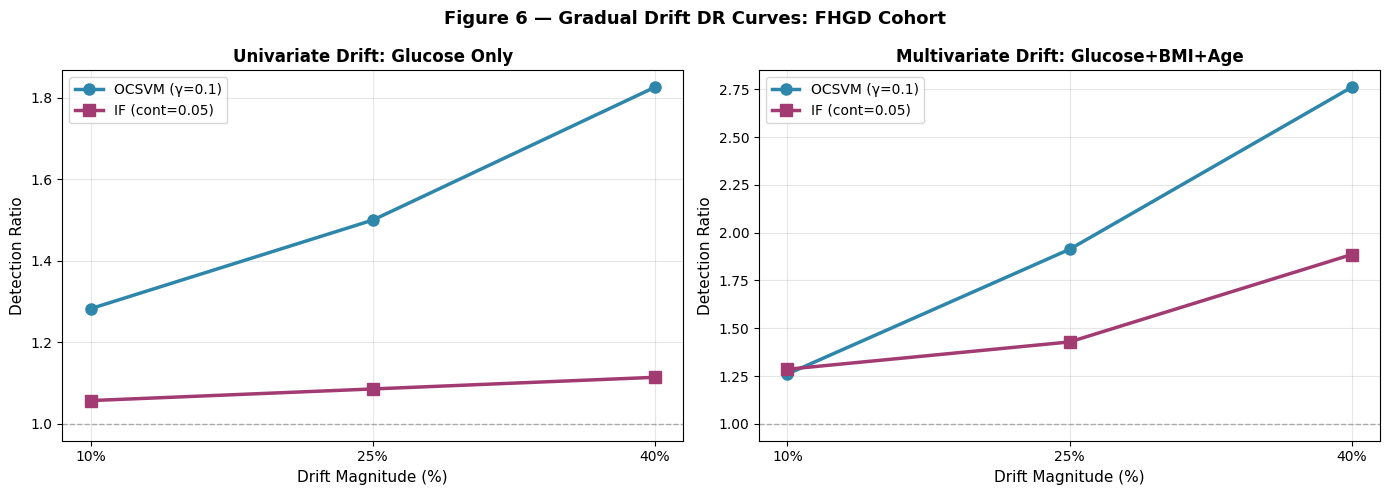


FHGD results stored.


In [22]:
# FHGD — Algorithm comparison + Figure 6 (cross-cohort DR)
ocsvm_f_uni_drs   = [r['detection_ratio'] for r in ocsvm_f_uni]
ocsvm_f_multi_drs = [r['detection_ratio'] for r in ocsvm_f_multi]
if_f_uni_drs      = [r['detection_ratio'] for r in if_f_uni]
if_f_multi_drs    = [r['detection_ratio'] for r in if_f_multi]

comp_rows_f = []
for i, dp in enumerate(drift_pcts):
    comp_rows_f.append({'Drift%': dp, 'Scenario': 'Univariate',
                        'OCSVM DR': round(ocsvm_f_uni_drs[i],3), 'IF DR': round(if_f_uni_drs[i],3),
                        'Advantage': 'IF' if if_f_uni_drs[i] > ocsvm_f_uni_drs[i] else 'OCSVM'})
    comp_rows_f.append({'Drift%': dp, 'Scenario': 'Multivariate',
                        'OCSVM DR': round(ocsvm_f_multi_drs[i],3), 'IF DR': round(if_f_multi_drs[i],3),
                        'Advantage': 'IF' if if_f_multi_drs[i] > ocsvm_f_multi_drs[i] else 'OCSVM'})
comp_df_f = pd.DataFrame(comp_rows_f)
print('\n--- FHGD: OCSVM vs Isolation Forest Detection Ratios ---')
display(comp_df_f)

# FHGD DR curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for ax, ocsvm_drs, if_drs, title in [
    (ax1, ocsvm_f_uni_drs,   if_f_uni_drs,   'Univariate Drift: Glucose Only'),
    (ax2, ocsvm_f_multi_drs, if_f_multi_drs, 'Multivariate Drift: Glucose+BMI+Age'),
]:
    ax.plot(drift_pcts, ocsvm_drs, marker='o', lw=2.5, ms=8, label='OCSVM (γ=0.1)', color='#2E86AB')
    ax.plot(drift_pcts, if_drs,    marker='s', lw=2.5, ms=8, label='IF (cont=0.05)', color='#A23B72')
    ax.axhline(1.0, color='grey', ls='--', lw=1, alpha=0.6)
    ax.set_xlabel('Drift Magnitude (%)', fontsize=11); ax.set_ylabel('Detection Ratio', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticks(drift_pcts); ax.set_xticklabels([f'{d}%' for d in drift_pcts])
    ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.suptitle('Figure 6 — Gradual Drift DR Curves: FHGD Cohort',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'fig6_gradual_DR_fhgd.png', dpi=150, bbox_inches='tight')
plt.show()

# Store
all_gradual_results['FHGD'] = dict(
    ocsvm_uni=ocsvm_f_uni, ocsvm_multi=ocsvm_f_multi,
    if_uni=if_f_uni,       if_multi=if_f_multi,
    zero_ocsvm=zero_rate_ocsvm_f, zero_if=zero_rate_if_f,
)
all_results_dfs.append(build_results_df(ocsvm_f_uni, ocsvm_f_multi, 'OCSVM', 'FHGD'))
all_results_dfs.append(build_results_df(if_f_uni,    if_f_multi,    'IF',    'FHGD'))
print('\nFHGD results stored.')

In [23]:
# ================================================================
# SECTION 3 — SAVE RESULTS & CROSS-COHORT SUMMARY
# ================================================================
results_df_all = pd.concat(all_results_dfs, ignore_index=True)
out_path = RESULTS_DIR / 'gradual_drift_results.csv'
results_df_all.to_csv(out_path, index=False)
print(f'All gradual drift results saved -> {out_path}')
display(results_df_all.round(3))

All gradual drift results saved -> data\results\gradual_drift_results.csv


,dataset,algorithm,scenario,drift_amount,outlier_original,outlier_drifted,detection_ratio
0,Pima,OCSVM,Univariate,0.10,0.117,0.117,1.000
1,Pima,OCSVM,Univariate,0.25,0.117,0.143,1.222
2,Pima,OCSVM,Univariate,0.40,0.117,0.173,1.481
3,Pima,OCSVM,Multivariate,0.10,0.117,0.121,1.037
4,Pima,OCSVM,Multivariate,0.25,0.117,0.169,1.444
5,Pima,OCSVM,Multivariate,0.40,0.117,0.242,2.074
6,Pima,IF,Univariate,0.10,0.022,0.026,1.200
7,Pima,IF,Univariate,0.25,0.022,0.026,1.200
8,Pima,IF,Univariate,0.40,0.022,0.035,1.600
9,Pima,IF,Multivariate,0.10,0.022,0.039,1.800


In [24]:
# Cross-cohort comparison at peak severity (40%)
peak = results_df_all[results_df_all['drift_amount'] == 0.40].copy()
peak['drift_pct'] = '40%'

print('\n=== PEAK DETECTION RATIO SUMMARY (40% Drift) ===')
pivot = peak.pivot_table(index=['dataset','scenario'], columns='algorithm',
                          values='detection_ratio').round(3)
pivot['Leading'] = pivot.apply(lambda row: 'IF' if row.get('IF',0) > row.get('OCSVM',0) else 'OCSVM', axis=1)
display(pivot)

print('\nGradual drift notebook complete.')
print('Results saved to data/results/gradual_drift_results.csv')
print('Next step: run 03_Abrupt_Drift.ipynb')


=== PEAK DETECTION RATIO SUMMARY (40% Drift) ===


algorithm                IF  OCSVM Leading
dataset scenario                          
FHGD    Multivariate  1.886  2.761   OCSVM
        Univariate    1.114  1.826   OCSVM
Pima    Multivariate  4.400  2.074      IF
        Univariate    1.600  1.481      IF


Gradual drift notebook complete.
Results saved to data/results/gradual_drift_results.csv
Next step: run 03_Abrupt_Drift.ipynb
